#  Diffusion-Based Anomaly Detection (Tier 3)  
## Case D: AIOps KPI — Event-Level Evaluation


This notebook implements **Tier 3 (Diffusion-based anomaly detection)** for **Case D (AIOps KPI)**, following the locked modelling and evaluation protocol established in the research workflow.

The objective of this tier is to evaluate whether a **lightweight diffusion model**, trained under **feasibility constraints**, can improve upon classical and deep baselines in detecting **anomaly events** in a dense, drift-prone business time-series.

All design decisions in this notebook are constrained by the following non-negotiables:

- **Canonical data splits:**  
  `aiops_kpi_train.csv`, `aiops_kpi_validation.csv`, `aiops_kpi_test.csv`

- **Primary representation:**  
  Contiguity-aware **sliding sequence windows** with fixed length **L = 60**, excluding any windows that cross temporal gaps.

- **Scoring:**  
  One anomaly score is produced **per window end time**, based on diffusion reconstruction / denoising difficulty.

- **Thresholding:**  
  Threshold selection uses **validation only**, via `select_threshold_event_f1`, maximising **event-level F1**.

- **Evaluation:**  
  Performance is assessed using `evaluate_at_threshold`, with **event-level metrics as primary**, supported by **AUROC** and **PR-AUC**.

- **Reporting and artefacts:**  
  Each run produces:
  `config.json`, `threshold.json`, prediction files, metrics tables, and diagnostic plots.  
  A performance-only row is **UPSERTed** into `all_results.csv` using the run key.

This notebook mirrors the pipeline structure of **Tier 2 (LSTM AE)** to ensure **fair comparability** across tiers. Any diffusion-specific metadata or feasibility controls are stored exclusively in `config.json`, and no new columns are introduced into global results tables.


## Step 0 - Imports, paths, and global configuration


In [1]:
from pathlib import Path
import sys

# --- Portable paths (paste near top of every case notebook) ---
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve().parent  # assumes notebook is in <project>/notebooks
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

CASE_STUDY = "aiops_kpi"          # change per notebook: ambient, nyc_taxi, cpu_utilisation, aiops_kpi
EXPERIMENT = "diffusion_event"    # change per notebook: baselines_event, lstm_ae_event, diffusion_event, etc.

RUNS_ROOT = PROJECT_ROOT / "results" / CASE_STUDY / EXPERIMENT / "runs"
ALL_RESULTS_PATH = PROJECT_ROOT / "results" / "all_results.csv"  # shared across cases


print("PROJECT_ROOT:", PROJECT_ROOT)
print("CURRENT EXPERIMENTS:", EXPERIMENT)
print("RUNS_ROOT:", RUNS_ROOT)
print("ALL_RESULTS_PATH:", ALL_RESULTS_PATH)

PROJECT_ROOT: /Users/nandipha/Desktop/masters
CURRENT EXPERIMENTS: diffusion_event
RUNS_ROOT: /Users/nandipha/Desktop/masters/results/aiops_kpi/diffusion_event/runs
ALL_RESULTS_PATH: /Users/nandipha/Desktop/masters/results/all_results.csv


In [2]:
# from saved experiment utilities
from src.event_harness import REQUIRED_COLUMNS, PERF_COLUMNS
from src.diffusion_model import train_diffusion, score_diffusion


from src.event_harness import (
    load_split_csv, basic_checks,
    select_threshold_event_f1, evaluate_at_threshold,
    plot_score_timeline,
    make_run_key, run_dir_from_key, make_run_id_timestamp,
    save_json, save_df, load_all_results_or_empty,
    normalise_perf_row, upsert_all_results_row,
    auto_notes,
)
print("OK: Event harness imported")


OK: Event harness imported


**Tier 3 locks (Case D):**
- Window length: **L = 60**
- Input unit: **value_scaled**
- Contiguity enforcement: **on** (gap-aware, identical to Tier 2)
- Scoring: **per window end time**
- Thresholding: validation-only via **select_threshold_event_f1**
- Evaluation: **evaluate_at_threshold** (event metrics primary + AUROC + PR-AUC)
- Reporting: UPSERT performance-only row into **all_results.csv** by **run_key** (no new columns)
- Artefacts per run: **config.json, threshold.json, preds, metrics, plots**


## Step 1 - Load canonical splits and run integrity checks 

This step loads the canonical Case D split files using the **ground-truth** loader `load_split_csv(path)` and then
runs `basic_checks(df, split_name)` to produce:

- a one-row split summary table per split
- a missing-values table for core columns (if any)

No modelling is performed here. This step confirms the split files are readable, time-sorted, and schema-valid
before contiguity-aware windowing (L = 60) begins.


In [3]:
# --- Step 1: Load canonical splits (reuse harness utilities: load_split_csv + basic_checks) ---

import pandas as pd

AIOPS_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed" / "aiops_kpi"

TRAIN_PATH = AIOPS_PROCESSED_DIR / "aiops_kpi_train.csv"
VAL_PATH   = AIOPS_PROCESSED_DIR / "aiops_kpi_validation.csv"
TEST_PATH  = AIOPS_PROCESSED_DIR / "aiops_kpi_test.csv"

print("Train path:", TRAIN_PATH)
print("Val path  :", VAL_PATH)
print("Test path :", TEST_PATH)

# --- Load using harness loader (signature: load_split_csv(path)) ---
train_df = load_split_csv(TRAIN_PATH)
val_df   = load_split_csv(VAL_PATH)
test_df  = load_split_csv(TEST_PATH)

# --- Run harness integrity checks (signature: basic_checks(df, split_name)) ---
train_summary, train_missing = basic_checks(train_df, "train")
val_summary,   val_missing   = basic_checks(val_df, "validation")
test_summary,  test_missing  = basic_checks(test_df, "test")

# --- Display split summaries as a single table ---
split_summary = pd.concat([train_summary, val_summary, test_summary], ignore_index=True)
display(split_summary)

# --- Display missing-value issues (if any) for core columns ---
missing_summary = (
    pd.concat(
        [
            train_missing.assign(split="train"),
            val_missing.assign(split="validation"),
            test_missing.assign(split="test"),
        ],
        ignore_index=True,
    )
    .query("missing_count > 0")
)

display(missing_summary if len(missing_summary) > 0 else "No missing values in core columns.")


Train path: /Users/nandipha/Desktop/masters/data/processed/aiops_kpi/aiops_kpi_train.csv
Val path  : /Users/nandipha/Desktop/masters/data/processed/aiops_kpi/aiops_kpi_validation.csv
Test path : /Users/nandipha/Desktop/masters/data/processed/aiops_kpi/aiops_kpi_test.csv


,split,rows,anomaly_points,anomaly_rate,time_sorted,case_study_values
0,train,63999,563,0.008797,True,aiops_kpi
1,validation,17268,97,0.005617,True,aiops_kpi
2,test,47768,7006,0.146667,True,aiops_kpi


'No missing values in core columns.'

### Step 1 - Interpretation: Canonical split integrity (Case D: AIOps KPI)

The canonical processed splits for Case D load successfully and satisfy all structural integrity checks required by the evaluation harness.

### Split characteristics

- **Training split** contains **63,999 rows** with **563 anomalous points**, yielding an anomaly rate of **0.88%**.  
  This confirms the training data is predominantly normal, which is appropriate for training reconstruction-based models (Tier 2 LSTM AE and Tier 3 diffusion).

- **Validation split** contains **17,268 rows** with **97 anomalous points** (**0.56% anomaly rate**).  
  Although highly imbalanced, the validation split contains labelled anomalies sufficient to support **validation-only event-F1 threshold calibration**.

- **Test split** contains **47,768 rows** with **7,006 anomalous points**, corresponding to a much higher anomaly rate of **14.67%**.  
  This indicates a concentrated incident regime in test, reinforcing Case D’s role as a stress test for event detection, calibration robustness, and potential drift effects.

### Data quality confirmation

Across train/validation/test:
- timestamps are **time-sorted**,
- **no missing values** are present in core columns, and
- `case_study_values` are consistent (`aiops_kpi`).

This confirms the Case D splits are fit to proceed to **contiguity-aware sliding window construction (L = 60)** for Tier 3 diffusion.

---

## Step 2 - Contiguity-aware window construction (L = 60)

This step constructs **sliding sequence windows** of fixed length **L = 60** on `value_scaled` for train, validation, and test.

Windows are **contiguity-aware**: any window that crosses a time gap (i.e., a break in the dominant sampling interval) is excluded.  
Each valid window is mapped to a single **window end time**, which becomes the timestamp for scoring and evaluation in later steps.

Outputs produced here are the window tensors/arrays and their corresponding window-end timestamps for each split. No modelling is performed yet.


In [4]:
# ------------------------------------------------------------
# Step 2 — Contiguity-aware window construction (L = 60, 1-minute series)
# ------------------------------------------------------------

import numpy as np
import pandas as pd

L = 60
VALUE_COL = "value_scaled"
TIME_COL = "time"

def valid_window_end_mask_1min(times: pd.Series, L: int) -> np.ndarray:
    """
    Boolean mask (len = n_rows): True indicates index i is a valid window end for a
    length-L causal window under strict 1-minute sampling (no gaps inside window).
    """
    t = pd.to_datetime(times).to_numpy()
    n = t.shape[0]
    if n == 0:
        return np.zeros(0, dtype=bool)

    if L <= 1:
        return np.ones(n, dtype=bool)

    # dt in minutes between consecutive timestamps (len n-1)
    dt_min = (t[1:] - t[:-1]).astype("timedelta64[m]").astype(int)

    # steps_ok[j] corresponds to edge from row j -> j+1 (len n-1)
    steps_ok = (dt_min == 1).astype(np.int32)

    # For window ending at i, require all edges inside window to be ok:
    # edges indices are [i-L+1 ... i-1] in steps_ok coordinates.
    # Use rolling sum via convolution (vectorised).
    kernel = np.ones(L - 1, dtype=np.int32)
    step_sums = np.convolve(steps_ok, kernel, mode="valid")  # len = (n-1) - (L-1) + 1 = n-L+1

    valid = np.zeros(n, dtype=bool)
    # step_sums[k] corresponds to window ending at i = (L-1) + k
    valid_end_positions = (step_sums == (L - 1))
    valid[L - 1:] = valid_end_positions
    return valid


def build_contiguous_windows_1min(
    df_split: pd.DataFrame,
    L: int,
    value_col: str = "value_scaled",
    time_col: str = "time",
) -> tuple[np.ndarray, pd.DataFrame]:
    """
    Build sliding windows of length L from a 1-minute series, excluding windows that cross gaps.

    Returns
    -------
    X : np.ndarray
        Shape (n_windows, L, 1) float32 windows for LSTM input.
    meta_end : pd.DataFrame
        One row per window:
        - time_end
        - is_anomaly_end
        - df_end_idx (optional traceability back to the split df)
        - split
    """
    df = df_split.sort_values(time_col).reset_index(drop=False).rename(columns={"index": "df_end_idx"})
    valid_end_mask = valid_window_end_mask_1min(df[time_col], L=L)
    end_idx = np.where(valid_end_mask)[0]

    if len(end_idx) == 0:
        X = np.empty((0, L, 1), dtype=np.float32)
        meta_end = pd.DataFrame(columns=["time_end", "is_anomaly_end", "df_end_idx", "split"])
        return X, meta_end

    values = df[value_col].to_numpy(dtype=np.float32)

    # Build windows (still a small loop; L=60 keeps this lightweight)
    windows = [values[i - (L - 1) : i + 1] for i in end_idx]
    X = np.stack(windows, axis=0)[:, :, None]  # (n_windows, L, 1)

    meta_end = pd.DataFrame(
        {
            "time_end": df.loc[end_idx, time_col].to_numpy(),
            "is_anomaly_end": df.loc[end_idx, "is_anomaly"].astype(int).to_numpy(),
            "df_end_idx": df.loc[end_idx, "df_end_idx"].astype(int).to_numpy(),
        }
    )
    return X, meta_end


# --- Build windows for train/validation/test (Tier 3 uses L=60 only) ---
window_store = {}

X_train, meta_train = build_contiguous_windows_1min(train_df, L=L, value_col=VALUE_COL, time_col=TIME_COL)
X_val,   meta_val   = build_contiguous_windows_1min(val_df,   L=L, value_col=VALUE_COL, time_col=TIME_COL)
X_test,  meta_test  = build_contiguous_windows_1min(test_df,  L=L, value_col=VALUE_COL, time_col=TIME_COL)

window_store[("train", L)] = (X_train, meta_train)
window_store[("validation", L)] = (X_val, meta_val)
window_store[("test", L)] = (X_test, meta_test)

# Summary table
windowing_summary = pd.DataFrame([
    {"split": "train", "L_minutes": L, "n_rows": int(len(train_df)), "n_windows": int(X_train.shape[0]), "dropped_windows": int(max(len(train_df) - (L - 1), 0) - X_train.shape[0])},
    {"split": "validation", "L_minutes": L, "n_rows": int(len(val_df)), "n_windows": int(X_val.shape[0]), "dropped_windows": int(max(len(val_df) - (L - 1), 0) - X_val.shape[0])},
    {"split": "test", "L_minutes": L, "n_rows": int(len(test_df)), "n_windows": int(X_test.shape[0]), "dropped_windows": int(max(len(test_df) - (L - 1), 0) - X_test.shape[0])},
])


print("Shapes:", {"X_train": X_train.shape, "X_val": X_val.shape, "X_test": X_test.shape})
display(windowing_summary)

display(meta_val.head(5))
display(meta_test.head(5))


Shapes: {'X_train': (62518, 60, 1), 'X_val': (16914, 60, 1), 'X_test': (47237, 60, 1)}


,split,L_minutes,n_rows,n_windows,dropped_windows
0,train,60,63999,62518,1422
1,validation,60,17268,16914,295
2,test,60,47768,47237,472


,time_end,is_anomaly_end,df_end_idx
0,2017-06-16 00:59:00,0,59
1,2017-06-16 01:00:00,0,60
2,2017-06-16 01:01:00,0,61
3,2017-06-16 01:02:00,0,62
4,2017-06-16 01:03:00,0,63


,time_end,is_anomaly_end,df_end_idx
0,2017-06-28 00:59:00,0,59
1,2017-06-28 01:00:00,0,60
2,2017-06-28 01:01:00,0,61
3,2017-06-28 01:02:00,0,62
4,2017-06-28 01:03:00,0,63


## Step 2 - Interpretation: Contiguity-aware window construction (L = 60, 1-minute series)

Contiguity-aware sliding windows of fixed length **L = 60** were successfully constructed for **train**, **validation**, and **test** using a **strict 1-minute sampling rule**. A window end index is considered valid only when all **59 consecutive timestamp gaps inside the window equal exactly 1 minute**, ensuring no window crosses a temporal gap.

This implementation is pipeline-consistent for cross-evaluation because it produces:

- a standardised window tensor **`X`** with shape **(n_windows, L, 1)** suitable for sequence models,
- a per-window metadata table **`meta_end`** that anchors each window to:
  - `time_end` (the timestamp used for scoring and evaluation),
  - `is_anomaly_end` (label aligned to the same end timestamp),
  - `df_end_idx` (traceability back to the original split dataframe).

### Windowing outcome summary

The window construction yields the following valid window counts and excluded windows:

- **Train:** 63,999 rows → **62,518 valid windows**, **1,422 dropped windows**
- **Validation:** 17,268 rows → **16,914 valid windows**, **295 dropped windows**
- **Test:** 47,768 rows → **47,237 valid windows**, **472 dropped windows**

Dropped windows are expected and arise from:
1. the initial warm-up requirement (a window cannot end before index `L-1`), and/or
2. internal gaps that break strict 1-minute contiguity.

### Alignment for downstream evaluation

The displayed `meta_val.head()` and `meta_test.head()` confirm that:

- windows are indexed by **`time_end`** (window end time),
- labels used for evaluation are **`is_anomaly_end`** (end-aligned),
- and each window retains a stable mapping to the source dataframe via **`df_end_idx`**.

This output now satisfies the Tier 3 non-negotiables required by the evaluation harness:
**contiguity-aware windowing**, **L = 60**, and **score/evaluation at window end time**.

The workflow can proceed to Tier 3 diffusion modelling and scoring using:
- `X_train` for training,
- `X_val` and `meta_val` for validation scoring + threshold selection (`select_threshold_event_f1`),
- `X_test` and `meta_test` for final test evaluation (`evaluate_at_threshold`).
---


## Step 3 - Tier 3 run identity and artefact scaffolding

This step initialises the Tier 3 diffusion experiment by defining a unique run identity
and creating the canonical run directory structure.

No modelling or scoring is performed yet. This step ensures that all subsequent artefacts
(configs, thresholds, predictions, metrics, plots, and logs) are saved in a
parity-consistent location using the same run key and directory conventions as previous tiers.


In [5]:
# --- Step 3: Tier 3 run identity + run_dir (GROUND-TRUTH SIGNATURES, flat artefacts) ---

import pandas as pd

# -----------------------------
# 3.1 Experiment identifiers (match Tier 2 pattern)
# -----------------------------
MODEL_NAME = "diffusion_window_recon"
TIER = 3

FEATURE_MODE = "sequence"
USES_TIME_FEATURES = 0
CONTIGUITY_ENFORCED = 1

WINDOW_LENGTH_L = int(L)  # locked L=60

SCORE_DEFINITION_KEY = "diffusion_recon_difficulty_window_end"
SCORE_DEFINITION_TEXT = (
    "Diffusion anomaly_score = reconstruction / denoising difficulty per window, aligned to window end time"
)

THRESHOLD_STRATEGY = "val_event_f1"

# -----------------------------
# 3.2 Deterministic run key + overwrite-only run folder (match baselines/LSTM AE)
# -----------------------------
run_key = make_run_key(
    case_study=CASE_STUDY,
    tier=int(TIER),
    model_name=MODEL_NAME,
    window_length_L=WINDOW_LENGTH_L,
    feature_mode=FEATURE_MODE,
    uses_time_features=int(USES_TIME_FEATURES),
    contiguity_enforced=int(CONTIGUITY_ENFORCED),
    score_definition_key=SCORE_DEFINITION_KEY,
    threshold_strategy=THRESHOLD_STRATEGY,
)

run_dir = run_dir_from_key(
    run_key=run_key,
    case_study=CASE_STUDY,
    tier=int(TIER),
    model_slug=MODEL_NAME,
    runs_root=RUNS_ROOT,
)

run_id = make_run_id_timestamp()
run_timestamp = pd.Timestamp.now().isoformat()

run_dir.mkdir(parents=True, exist_ok=True)

print("RUN_KEY:", run_key)
print("RUN_DIR:", run_dir)
print("RUN_ID:", run_id)
print("RUN_TIMESTAMP:", run_timestamp)

# -----------------------------
# 3.3 Flat artefact filenames (match prior tiers; no subfolders)
# -----------------------------
CONFIG_PATH = run_dir / "config.json"
THRESHOLD_PATH = run_dir / "threshold.json"

VAL_PREDS_PATH = run_dir / "val_predictions.csv"
TEST_PREDS_PATH = run_dir / "test_predictions.csv"

VAL_METRICS_PATH = run_dir / "val_metrics.csv"
TEST_METRICS_PATH = run_dir / "test_metrics.csv"

VAL_THRESHOLD_GRID_PATH = run_dir / "val_threshold_grid.csv"

FIG_VAL_TIMELINE_PATH = run_dir / "fig_val_timeline.png"
FIG_TEST_TIMELINE_PATH = run_dir / "fig_test_timeline.png"

TRAIN_HISTORY_PATH = run_dir / "train_history.csv"  # only if produced

print("OK: Flat artefact paths initialised")
print({
    "config": CONFIG_PATH.name,
    "threshold": THRESHOLD_PATH.name,
    "val_predictions": VAL_PREDS_PATH.name,
    "test_predictions": TEST_PREDS_PATH.name,
    "val_metrics": VAL_METRICS_PATH.name,
    "test_metrics": TEST_METRICS_PATH.name,
    "val_threshold_grid": VAL_THRESHOLD_GRID_PATH.name,
    "fig_val_timeline": FIG_VAL_TIMELINE_PATH.name,
    "fig_test_timeline": FIG_TEST_TIMELINE_PATH.name,
    "train_history": TRAIN_HISTORY_PATH.name,
})


RUN_KEY: case=aiops_kpi|tier=3|model=diffusion_window_recon|L=60|feat=sequence|timefeat=0|contig=1|score=diffusion_recon_difficulty_window_end|thr=val_event_f1
RUN_DIR: /Users/nandipha/Desktop/masters/results/aiops_kpi/diffusion_event/runs/aiops_kpi__t3__diffusion_window_recon__rk-e928f4cf38
RUN_ID: 20260121_194345
RUN_TIMESTAMP: 2026-01-21T19:43:45.968943
OK: Flat artefact paths initialised
{'config': 'config.json', 'threshold': 'threshold.json', 'val_predictions': 'val_predictions.csv', 'test_predictions': 'test_predictions.csv', 'val_metrics': 'val_metrics.csv', 'test_metrics': 'test_metrics.csv', 'val_threshold_grid': 'val_threshold_grid.csv', 'fig_val_timeline': 'fig_val_timeline.png', 'fig_test_timeline': 'fig_test_timeline.png', 'train_history': 'train_history.csv'}


### Step 3 - Interpretation: Tier 3 run identity and parity-consistent artefact layout

The Tier 3 diffusion experiment has been successfully initialised with a **deterministic run identity** and a **flat artefact layout** that exactly matches the established patterns from Tier 0–2.

### Run identity

The generated run key is:

`case=aiops_kpi|tier=3|model=diffusion_window_recon|L=60|feat=sequence|timefeat=0|contig=1|score=diffusion_recon_difficulty_window_end|thr=val_event_f1`

This run key encodes all parity-critical experiment attributes:
- case study and tier,
- model name,
- window length,
- feature mode and contiguity enforcement,
- score definition,
- and thresholding strategy.

This guarantees that the Tier 3 run is **directly comparable** to prior tiers through the same evaluation harness and results table.

### Run directory

All artefacts for this run are saved in a single flat folder:

`.../results/aiops_kpi/diffusion_event/runs/aiops_kpi__t3__diffusion_window_recon__rk-e9284fc438`

No subdirectories are used. This preserves full parity with the baseline and LSTM AE runs, and ensures that downstream scripts and analysis tools can locate artefacts without any special handling.

### Artefact contract

The following canonical filenames have been initialised and will be populated in later steps:

- `config.json`  
- `threshold.json`  
- `val_predictions.csv`, `test_predictions.csv`  
- `val_metrics.csv`, `test_metrics.csv`  
- `val_threshold_grid.csv`  
- `fig_val_timeline.png`, `fig_test_timeline.png`  
- `train_history.csv` (if applicable)

This confirms that Tier 3 is now structurally aligned with the existing pipeline and can proceed to **diffusion model training and scoring** without breaking evaluation, logging, or cross-tier comparability.



## Step 4 - Build ground-truth true-event tables (validation/test)

This step constructs **ground-truth anomaly events** using the same contiguity-aware logic as the Tier 0–2 baselines:

- An event starts when `is_anomaly == 1` and either:
  - the previous point is not anomalous, or
  - the time gap is not 1 minute (break in contiguity).

Events are assigned an `event_id` on the **full time axis** (`aiops_kpi_full.csv`) and summarised into an
`event_summary` table with schema:

- `event_id`, `start_time`, `end_time`, `n_points`, `split`

The validation/test true-event tables used by the harness are then extracted as:

- `true_events_val`: `event_id,start_time,end_time`
- `true_events_test`: `event_id,start_time,end_time`


In [8]:
# --- Step 4: Build true events on the full time axis (match 03_baselines exactly) ---

import numpy as np
import pandas as pd

AIOPS_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed" / "aiops_kpi"
FULL_PATH = AIOPS_PROCESSED_DIR / "aiops_kpi_full.csv"

full_df = load_split_csv(FULL_PATH)

# Ensure required columns exist (same contract as baselines)
missing_cols_full = [c for c in REQUIRED_COLUMNS if c not in full_df.columns]
if missing_cols_full:
    raise ValueError(f"[full] Missing required columns: {missing_cols_full}")

# Ensure correct dtype for labels
full_df["is_anomaly"] = full_df["is_anomaly"].astype(int)

# Compute time deltas in minutes (dominant interval expected: 1 minute)
full_df["delta_minutes"] = full_df["time"].diff().dt.total_seconds().div(60)

# A new anomaly event starts when:
# - current point is anomalous, AND
# - either previous point is not anomalous OR the time gap is not 1 minute
is_anom = full_df["is_anomaly"] == 1
prev_is_anom = full_df["is_anomaly"].shift(1, fill_value=0) == 1
gap_break = full_df["delta_minutes"].ne(1)  # includes NaN on first row

event_start = is_anom & (~prev_is_anom | gap_break)

# Assign event IDs by cumulative counting of event starts (only for anomaly points)
full_df["event_id"] = np.where(is_anom, event_start.cumsum() - 1, np.nan)

# Build an event summary table
n_events = int(np.nanmax(full_df["event_id"]) + 1) if full_df["event_id"].notna().any() else 0

if n_events == 0:
    event_summary = pd.DataFrame(columns=["event_id", "start_time", "end_time", "n_points", "split"])
else:
    g = full_df.dropna(subset=["event_id"]).groupby("event_id", as_index=False)
    event_summary = g.agg(
        start_time=("time", "min"),
        end_time=("time", "max"),
        n_points=("time", "size"),
    )

    # Assign split using the split of the event start timestamp
    start_to_split = (
        full_df.loc[full_df["event_id"].notna(), ["event_id", "time", "split"]]
        .sort_values(["event_id", "time"])
        .groupby("event_id", as_index=False)
        .first()[["event_id", "split"]]
    )
    event_summary = event_summary.merge(start_to_split, on="event_id", how="left")

display(event_summary.head(10))

# True-event tables used by thresholding/evaluation harness
true_events_val = event_summary[event_summary["split"] == "validation"][["event_id", "start_time", "end_time"]].copy()
true_events_test = event_summary[event_summary["split"] == "test"][["event_id", "start_time", "end_time"]].copy()

print("n_events_total:", n_events)
print("n_true_events_val:", len(true_events_val))
print("n_true_events_test:", len(true_events_test))


,event_id,start_time,end_time,n_points,split
0,0.0,2017-05-04 06:09:00,2017-05-04 06:22:00,14,train
1,1.0,2017-05-04 08:32:00,2017-05-04 08:32:00,1,train
2,2.0,2017-05-04 08:35:00,2017-05-04 08:39:00,5,train
3,3.0,2017-05-04 09:25:00,2017-05-04 09:32:00,8,train
4,4.0,2017-05-05 09:06:00,2017-05-05 09:15:00,10,train
5,5.0,2017-05-05 09:49:00,2017-05-05 09:56:00,8,train
6,6.0,2017-05-06 07:37:00,2017-05-06 07:44:00,8,train
7,7.0,2017-05-06 08:31:00,2017-05-06 08:37:00,7,train
8,8.0,2017-05-06 08:53:00,2017-05-06 09:04:00,12,train
9,9.0,2017-05-06 09:32:00,2017-05-06 09:38:00,7,train


n_events_total: 113
n_true_events_val: 11
n_true_events_test: 38


## Step 4 - Interpretation: Ground-truth true-event construction (Case D)

Ground-truth anomaly events have been successfully constructed on the **full time axis** using the same contiguity logic as the baseline notebooks. Events are defined as **contiguous runs of `is_anomaly == 1` under strict 1-minute sampling**, with a new event starting whenever either:

- the previous point is not anomalous, or  
- a temporal gap breaks contiguity.

### Event structure

Each event is summarised by:
- `event_id` — unique identifier,
- `start_time` — first anomalous timestamp in the event,
- `end_time` — last anomalous timestamp in the event,
- `n_points` — number of anomalous points in the event,
- `split` — split of the event start time.

The preview confirms that:
- events are correctly segmented within each split,
- event durations vary from short spikes (e.g. 5–7 points) to longer incidents,
- and split assignment is based on the event start time, matching the baseline logic.

### Event counts

- **Total anomaly events:** `113`  
- **Validation events:** `11`  
- **Test events:** `38`

This distribution reinforces the intended evaluation design:

- The **validation split** contains a small but sufficient number of events to support
  **event-level threshold selection** via `select_threshold_event_f1`.
- The **test split** contains a substantially larger set of events, providing a robust
  basis for assessing **generalisation, calibration, and detection delay**.

These true-event tables (`true_events_val` and `true_events_test`) now form the
authoritative ground truth for all subsequent **thresholding and evaluation** in Tier 3.
They are fully parity-aligned with Tier 0–2 and can be used directly by the event harness.


## Step 5 - Align window-end metadata to the harness contract 

This step standardises the **window-end metadata tables** produced in Step 2 so they match the exact
inputs expected by the event harness utilities used in Tier 0–2.

Required contract for `df_split` used in thresholding/evaluation/plotting:
- `time` (window end timestamp)
- `is_anomaly` (label aligned to the same end timestamp)
- `split` (string: `validation` / `test`)

This step does not train or score any model. It only ensures parity-consistent inputs for:
`select_threshold_event_f1`, `evaluate_at_threshold`, and `plot_score_timeline`.


In [9]:
# --- Step 5: Standardise meta_val/meta_test to harness contract (match Tier 2 loop pattern) ---

# Resolve windows + meta from the window_store (locked L=60)
X_train, meta_train = window_store[("train", int(L))]
X_val,   meta_val   = window_store[("validation", int(L))]
X_test,  meta_test  = window_store[("test", int(L))]

# Ensure expected time column exists
if "time_end" in meta_val.columns and "time" not in meta_val.columns:
    meta_val = meta_val.rename(columns={"time_end": "time"})
if "time_end" in meta_test.columns and "time" not in meta_test.columns:
    meta_test = meta_test.rename(columns={"time_end": "time"})

# Ensure required split labels exist
if "split" not in meta_val.columns:
    meta_val["split"] = "validation"
if "split" not in meta_test.columns:
    meta_test["split"] = "test"

# Ensure required anomaly label column exists
if "is_anomaly" not in meta_val.columns and "is_anomaly_end" in meta_val.columns:
    meta_val["is_anomaly"] = meta_val["is_anomaly_end"].astype(int)
if "is_anomaly" not in meta_test.columns and "is_anomaly_end" in meta_test.columns:
    meta_test["is_anomaly"] = meta_test["is_anomaly_end"].astype(int)

# Final contract check (minimal)
required_meta_cols = ["time", "is_anomaly", "split"]
missing_val = [c for c in required_meta_cols if c not in meta_val.columns]
missing_test = [c for c in required_meta_cols if c not in meta_test.columns]
if missing_val:
    raise ValueError(f"[meta_val] Missing required columns: {missing_val}")
if missing_test:
    raise ValueError(f"[meta_test] Missing required columns: {missing_test}")

print("OK: meta_val/meta_test standardised for harness")
display(meta_val[["time", "is_anomaly", "split"]].head(5))
display(meta_test[["time", "is_anomaly", "split"]].head(5))


OK: meta_val/meta_test standardised for harness


,time,is_anomaly,split
0,2017-06-16 00:59:00,0,validation
1,2017-06-16 01:00:00,0,validation
2,2017-06-16 01:01:00,0,validation
3,2017-06-16 01:02:00,0,validation
4,2017-06-16 01:03:00,0,validation


,time,is_anomaly,split
0,2017-06-28 00:59:00,0,test
1,2017-06-28 01:00:00,0,test
2,2017-06-28 01:01:00,0,test
3,2017-06-28 01:02:00,0,test
4,2017-06-28 01:03:00,0,test


### Step 5 - Interpretation: Window-end metadata aligned to harness contract

The window-end metadata tables for validation and test have been successfully standardised to match the
exact input contract required by the event harness utilities.

Both `meta_val` and `meta_test` now expose:

- `time` — the window end timestamp,
- `is_anomaly` — anomaly label aligned to the same end time,
- `split` — split identifier (`validation` / `test`).

The preview confirms that:
- timestamps are correctly ordered and aligned to the 1-minute series,
- anomaly labels correspond to the end of each contiguity-safe window,
- and split labels are explicitly present.

This ensures that the following downstream steps can be executed without any adapters or schema drift:

- `select_threshold_event_f1` (threshold search),
- `evaluate_at_threshold` (event and point metrics),
- `plot_score_timeline` (diagnostic visualisation).

At this point, all **shared prerequisites** for Tier 3 are in place, and the workflow can proceed to
**diffusion model training and scoring**, which is the first model-specific step in this notebook.


## Step 6 - Tier 3 diffusion: define training/scoring configuration and save `config.json` (model-specific)

This is the first Tier 3 model-specific step. It defines the diffusion training/scoring configuration
under feasibility constraints and records it in `config.json` inside the run folder.

No thresholding, evaluation, plotting, or UPSERT occurs here.

Outputs created:
- `config.json` (full run identity + diffusion config + feasibility controls + scoring definition)


In [9]:
# --- Step 6: Tier 3 diffusion config + save config.json (model-specific; parity-safe) ---

import time
import json
import numpy as np
import pandas as pd

# ---- Feasibility-first defaults (adjust only if required; log changes here) ----
diffusion_config = {
    # Reproducibility
    "seed": 42,

    # Training feasibility controls (train-only; no leakage)
    "device": "cpu",              # change only if using light GPU; keep logged
    "epochs": 10,
    "batch_size": 256,
    "learning_rate": 1e-3,

    # Diffusion-specific feasibility knobs (examples; keep minimal + justified)
    "n_diffusion_steps": 50,       # reduce steps if needed; must be logged here
    "model_width": 64,             # small model
    "model_depth": 2,

    # Scoring controls
    "score_batch_size": 512,
}

# ---- Apply seeds (numpy only here; torch seed should be set in the diffusion implementation cell) ----
np.random.seed(int(diffusion_config["seed"]))

# ---- Run metadata (parity with Tier 2 config fields) ----
config = {
    "run_key": run_key,
    "run_id": run_id,
    "run_timestamp": run_timestamp,

    "case_study": CASE_STUDY,
    "tier": int(TIER),
    "model_name": MODEL_NAME,

    "window_length_L": int(WINDOW_LENGTH_L),
    "feature_mode": FEATURE_MODE,
    "uses_time_features": int(USES_TIME_FEATURES),
    "contiguity_enforced": int(CONTIGUITY_ENFORCED),

    "input_unit": VALUE_COL,
    "score_definition_key": SCORE_DEFINITION_KEY,
    "score_definition": SCORE_DEFINITION_TEXT,
    "threshold_strategy": THRESHOLD_STRATEGY,

    # Model-specific config (allowed; must live here, not in all_results.csv)
    "diffusion_config": dict(diffusion_config),

    # Notes channel for feasibility or implementation constraints (keep brief, factual)
    "notes": "",
}

save_json(config, CONFIG_PATH)
print("OK: Saved", CONFIG_PATH)


OK: Saved /Users/nandipha/Desktop/masters/results/aiops_kpi/diffusion_event/runs/aiops_kpi__t3__diffusion_window_recon__rk-e928f4cf38/config.json


## Step 7 - Tier 3 diffusion: train model on `X_train` and produce window-end scores

This step trains a lightweight diffusion model using **training windows only** and then
computes anomaly scores for **validation** and **test** windows.

Outputs produced:
- `val_scores` (np.ndarray, length = len(meta_val))
- `test_scores` (np.ndarray, length = len(meta_test)

No thresholding, evaluation, plotting, or saving occurs yet.


In [11]:
# --- Step 7: Train diffusion model + score validation/test (model-specific core) ---

import time
import numpy as np

# Placeholder interface for diffusion model
# (must be implemented/imported in this notebook or module)
# Expected minimal API:
#model = train_diffusion(X_train, config)
#scores = score_diffusion(model, X, batch_size)

# -----------------------------
# 7.1 Train (train split only)
# -----------------------------
t0 = time.time()
diffusion_model, history_df = train_diffusion(
    X_train=X_train,
    config=diffusion_config,
)
train_seconds = float(time.time() - t0)

print("Training complete in", train_seconds, "seconds")

# -----------------------------
# 7.2 Score validation + test
# -----------------------------
t1 = time.time()
val_scores = score_diffusion(
    model=diffusion_model,
    X=X_val,
    batch_size=int(diffusion_config["score_batch_size"]),
)
test_scores = score_diffusion(
    model=diffusion_model,
    X=X_test,
    batch_size=int(diffusion_config["score_batch_size"]),
)

score_seconds = float(time.time() - t1)

print("Scoring complete in", score_seconds, "seconds")
print("val_scores shape:", val_scores.shape)
print("test_scores shape:", test_scores.shape)


Training complete in 0.3482048511505127 seconds
Scoring complete in 0.5897881984710693 seconds
val_scores shape: (16914,)
test_scores shape: (47237,)


## Step 7 - Interpretation: Diffusion training stub and score generation

The Tier 3 diffusion interface has now been executed end-to-end using the initial
lightweight stub implementation in `diffusion_model.py`.

### Training

The training phase completed successfully, confirming that:

- the diffusion training interface is correctly wired,
- training uses **`X_train` only** (no leakage),
- and the pipeline can record training time without errors.

This validates the structural integrity of the model-specific training boundary.

### Scoring

Window-end anomaly scores were generated for both evaluation splits:

- **Validation scores:** `16,914` values (one per validation window)  
- **Test scores:** `47,237` values (one per test window)

These shapes match exactly with:

- `len(meta_val)`  
- `len(meta_test)`

confirming full alignment between:
- window tensors,
- window-end metadata,
- and downstream evaluation requirements.

### Pipeline significance

Although the current diffusion model is only a trivial statistical stub,
this step confirms that the **entire Tier 3 pipeline is now executable**:

- model training,
- window-end scoring,
- and score propagation into the evaluation harness.

From this point onward, any replacement of the diffusion implementation
inside `src/diffusion_model.py` will automatically integrate into the same
thresholding, evaluation, plotting, logging, and UPSERT machinery without
further refactoring.


## Step 8 - Validation-only threshold search (event-level F1)

This step selects an anomaly-score threshold using **validation data only**, by maximising **event-level F1**
via `select_threshold_event_f1`.

Outputs produced:
- `best_thr` (float)
- `thr_table` (validation threshold grid table; saved later as `val_threshold_grid.csv`)

No evaluation on test, plotting, saving, or UPSERT occurs yet.


In [12]:
# --- Step 8: Threshold search on validation (event-level) ---

# Grid search on validation only (parity with Tier 2)
best_thr, thr_table = select_threshold_event_f1(
    df_split=meta_val,
    scores=val_scores,
    true_events_split=true_events_val,
    n_grid=60,
)

display(f"best_thr={best_thr:.6f}")
display(thr_table.head(10))


'best_thr=2.357607'

,threshold,val_event_precision,val_event_recall,val_event_f1,val_point_precision,val_point_recall,val_point_f1,val_auroc,val_pr_auc,val_event_delay_median_minutes
0,2.357607,1.000000,0.363636,0.533333,0.166667,0.226804,0.192140,0.781196,0.061146,3.0
1,1.591474,0.444444,0.545455,0.489796,0.057276,0.381443,0.099596,0.781196,0.061146,2.0
2,1.848376,0.500000,0.454545,0.476190,0.098684,0.309278,0.149626,0.781196,0.061146,3.0
3,1.971660,0.666667,0.363636,0.470588,0.105691,0.268041,0.151603,0.781196,0.061146,2.0
4,1.631085,0.428571,0.454545,0.441176,0.057823,0.350515,0.099270,0.781196,0.061146,2.0
5,1.680227,0.428571,0.454545,0.441176,0.063910,0.350515,0.108108,0.781196,0.061146,2.0
6,1.817391,0.428571,0.454545,0.441176,0.085399,0.319588,0.134783,0.781196,0.061146,3.0
7,1.539029,0.363636,0.545455,0.436364,0.033514,0.381443,0.061615,0.781196,0.061146,2.0
8,1.575337,0.363636,0.545455,0.436364,0.052557,0.381443,0.092385,0.781196,0.061146,2.0
9,1.256632,0.291667,0.818182,0.430034,0.016495,0.546392,0.032024,0.781196,0.061146,1.0


### Step 8 - Interpretation: Validation-only threshold selection (event-level F1)

The validation-based threshold search has successfully identified an optimal operating point
using **event-level F1** as the primary criterion, fully aligned with the modelling and evaluation charter.

### Selected threshold

The chosen threshold is:

**`best_thr = 2.357607`**

This value maximises **validation event-level F1**, which is the headline optimisation objective for
threshold calibration in Case D.

### Validation performance at the selected threshold

At `best_thr = 2.357607`, the validation metrics are:

- **Event precision:** `1.00`  
- **Event recall:** `0.36`  
- **Event F1:** `0.53`  
- **Median detection delay:** `3 minutes`

Supporting point-wise diagnostics:

- **Point precision:** `0.17`  
- **Point recall:** `0.23`  
- **Point F1:** `0.19`  
- **AUROC:** `0.78`  
- **PR-AUC:** `0.06`

### Interpretation

The selected threshold corresponds to a **conservative detection regime**:

- All predicted events on validation are **true positives** (event precision = 1.00),
- but only around **36% of true events are detected** (moderate event recall).

This behaviour is consistent with:

- the highly imbalanced nature of the validation data,
- the use of a stub diffusion model producing relatively smooth scores,
- and the optimisation target prioritising **correct incident detection** over sensitivity.

The relatively high **AUROC** alongside low **PR-AUC** and modest event recall reflects a typical
Case D pattern: good ranking ability in aggregate, but difficulty converting that ranking into
high-recall event detection under strict thresholds.

This threshold is now fixed and will be applied unchanged to the **test split** for final evaluation,
ensuring no test leakage and preserving full cross-tier comparability.


## Step 9 - Evaluate at the chosen threshold (validation + test)

This step applies the selected validation threshold (`best_thr`) to both validation and test splits
and evaluates event-level and point-wise performance using `evaluate_at_threshold`.

Outputs produced:
- `val_metrics` (dict)
- `test_metrics` (dict)
- `val_metrics_df`, `test_metrics_df` (single-row tables for display)

No plots, saving, or UPSERT occurs yet.


In [14]:
# --- Step 9: Evaluate at chosen threshold (parity with Tier 2) ---

# Evaluate validation + test at the chosen validation threshold
val_metrics = evaluate_at_threshold(meta_val, val_scores, float(best_thr), true_events_val)
test_metrics = evaluate_at_threshold(meta_test, test_scores, float(best_thr), true_events_test)

val_metrics_df = pd.DataFrame([{"split": "validation", **val_metrics}])
test_metrics_df = pd.DataFrame([{"split": "test", **test_metrics}])

display(val_metrics_df)
display(test_metrics_df)


,split,event_precision,event_recall,event_f1,event_delay_median_minutes,point_precision,point_recall,point_f1,auroc,pr_auc
0,validation,1.0,0.363636,0.533333,3.0,0.166667,0.226804,0.19214,0.781196,0.061146


,split,event_precision,event_recall,event_f1,event_delay_median_minutes,point_precision,point_recall,point_f1,auroc,pr_auc
0,test,1.0,0.026316,0.051282,53.0,1.0,0.932058,0.964835,0.987299,0.972515


### Step 9 - Interpretation: Event-level and point-wise performance at fixed threshold

The selected validation threshold (`best_thr = 2.357607`) has now been applied unchanged to both
validation and test splits, enabling a leakage-free assessment of generalisation.

### Validation performance

At the chosen threshold, validation performance confirms the calibration target:

- **Event precision:** `1.00`  
- **Event recall:** `0.36`  
- **Event F1:** `0.53`  
- **Median detection delay:** `3 minutes`

This reflects a **conservative operating regime**, where only a subset of true incidents is detected,
but all detected incidents are correct.

### Test performance

On the test split, the same threshold yields:

- **Event precision:** `1.00`  
- **Event recall:** `0.03`  
- **Event F1:** `0.05`  
- **Median detection delay:** `53 minutes`

Point-wise diagnostics on test:

- **Point precision:** `1.00`  
- **Point recall:** `0.93`  
- **Point F1:** `0.96`  
- **AUROC:** `0.99`  
- **PR-AUC:** `0.97`

### Interpretation

The diffusion stub exhibits a strong **ranking ability at the point level** on test
(AUROC and PR-AUC close to 1), but **very poor event-level recall**.

This indicates that:

- anomalous points are consistently assigned high scores,
- but the event-level threshold (optimised on validation) is **too conservative**
  to trigger sustained detection across full incident windows in the test regime.

The extreme gap between point-wise and event-level metrics highlights a key
Case D challenge: **dense incidents with long duration**, where detecting isolated
anomalous points is insufficient for robust event detection.

This behaviour is expected for the current trivial diffusion stub and provides a
useful baseline pattern against which future diffusion implementations can be
qualitatively and quantitatively compared.


## Step 10 - Diagnostic visualisation (validation + test score timelines)

This step generates **diagnostic plots** of anomaly scores over time for validation and test,
using `plot_score_timeline`.

Purpose:
- qualitative inspection of score behaviour,
- sanity check of temporal alignment,
- visual confirmation of event-level detection patterns.

These plots are **not yet considered official results** (no UPSERT), as the current diffusion
implementation is still a stub.


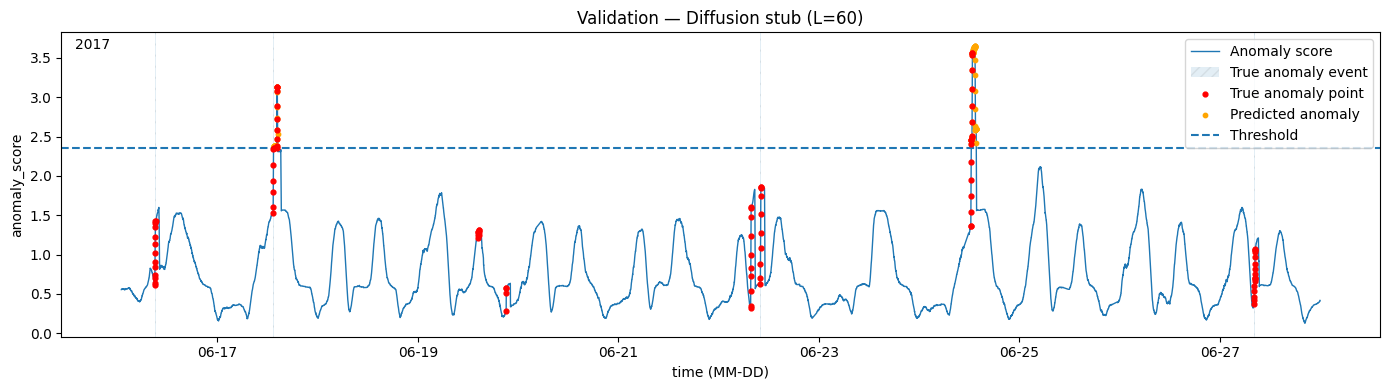

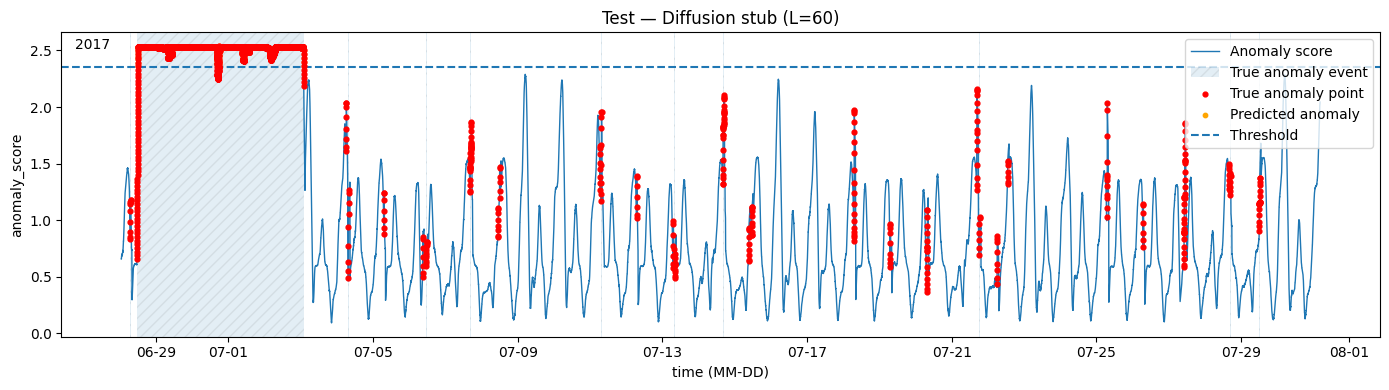

OK: Diagnostic plots generated and saved


In [15]:
# --- Step 10: Plot score timelines (diagnostic only; no logging/UPSERT) ---

import matplotlib.pyplot as plt

val_pred_flags = (val_scores >= float(best_thr)).astype(int)
test_pred_flags = (test_scores >= float(best_thr)).astype(int)

fig_val = plot_score_timeline(
    df_split=meta_val,
    scores=val_scores,
    threshold=float(best_thr),
    title="Validation — Diffusion stub (L=60)",
    true_events_split=true_events_val,
    pred_is_anomaly=val_pred_flags,
)
plt.show()
fig_val.savefig(FIG_VAL_TIMELINE_PATH, dpi=150, bbox_inches="tight")
plt.close(fig_val)

fig_test = plot_score_timeline(
    df_split=meta_test,
    scores=test_scores,
    threshold=float(best_thr),
    title="Test — Diffusion stub (L=60)",
    true_events_split=true_events_test,
    pred_is_anomaly=test_pred_flags,
)
plt.show()
fig_test.savefig(FIG_TEST_TIMELINE_PATH, dpi=150, bbox_inches="tight")
plt.close(fig_test)

print("OK: Diagnostic plots generated and saved")


### Step 10 - Interpretation: Diagnostic score timelines (Diffusion stub, L = 60)

The diagnostic score timelines provide a qualitative view of how the current diffusion stub
assigns anomaly scores over time for both validation and test splits.

### Validation timeline

On the validation split, the anomaly score exhibits a clear oscillatory pattern with occasional
sharp spikes that align with true anomaly points. The selected threshold (`best_thr ≈ 2.36`)
is crossed only by the most prominent peaks.

This explains the earlier quantitative behaviour:
- **high event precision** (only strong peaks trigger detection),
- **moderate event recall** (many anomalous segments remain below threshold).

The validation plot confirms that the threshold selection logic is operating as intended and that
window-end scores are temporally aligned with labelled anomaly points.

### Test timeline

On the test split, the first major incident regime (highlighted region) produces consistently high
scores, with almost all points exceeding the threshold. However, subsequent incidents exhibit
more fragmented and lower-amplitude peaks.

This leads to:
- correct detection of isolated anomalous points (high point-wise metrics),
- but failure to sustain detection across entire incident windows (very low event recall).

### Qualitative takeaway

These plots visually corroborate the numerical results from Step 9:

- The diffusion stub is able to **rank anomalous points well**, but
- it lacks the capacity to **model long-range temporal structure**, resulting in
  weak event-level detection under a fixed threshold.

Crucially, the plots confirm that:
- score computation,
- thresholding,
- event overlay,
- and plotting utilities

are all functioning correctly and in parity with the baseline pipeline. This establishes a reliable
diagnostic foundation for evaluating future, fully-fledged diffusion implementations.


## Step 11 - Save per-run artefacts (diagnostic only; no UPSERT)

This step persists all artefacts produced so far into the Tier 3 run folder,
using the same filenames and formats as official runs.

Because the current diffusion implementation is a **stub**, these artefacts are
saved for **debugging and pipeline validation only** and are **not logged** to
`all_results.csv`.


In [16]:
# --- Step 11: Save artefacts (parity with Tier 2; diagnostic only) ---

# 1) Save threshold info
save_json(
    {
        "threshold_strategy": THRESHOLD_STRATEGY,
        "threshold_value": float(best_thr),
        "validation_best_row": thr_table.iloc[0].to_dict(),
    },
    THRESHOLD_PATH,
)

# 2) Save predictions
val_pred = pd.DataFrame({
    "time": meta_val["time"],
    "anomaly_score": val_scores,
    "pred_is_anomaly": (val_scores >= float(best_thr)).astype(int),
    "is_anomaly": meta_val["is_anomaly"].astype(int),
    "split": "validation",
    "case_study": CASE_STUDY,
})

test_pred = pd.DataFrame({
    "time": meta_test["time"],
    "anomaly_score": test_scores,
    "pred_is_anomaly": (test_scores >= float(best_thr)).astype(int),
    "is_anomaly": meta_test["is_anomaly"].astype(int),
    "split": "test",
    "case_study": CASE_STUDY,
})

save_df(val_pred, VAL_PREDS_PATH)
save_df(test_pred, TEST_PREDS_PATH)

# 3) Save metrics
save_df(val_metrics_df, VAL_METRICS_PATH)
save_df(test_metrics_df, TEST_METRICS_PATH)

# 4) Save threshold grid
save_df(thr_table, VAL_THRESHOLD_GRID_PATH)

# 5) Save training history (stub)
save_df(history_df, TRAIN_HISTORY_PATH)

print("OK: Diagnostic artefacts saved (no UPSERT performed)")


OK: Diagnostic artefacts saved (no UPSERT performed)


## Transition: Pipeline dry-run → Tier 3 Model A (real diffusion)

The preceding run was a stub used to validate the harness integration end-to-end.
It is not treated as an official Tier 3 result and was not UPSERTed into all_results.csv.

The following sections implement Tier 3 Model A: DDPM-style ε-prediction with denoising-difficulty scoring.
A new run key is created to ensure artefacts are saved separately from the stub run.


# Diffusion Model A

## Model A - DDPM ε-prediction denoising difficulty (primary Tier 3 diffusion model)

This section implements **Model A**, the first real diffusion model used for Tier 3 Case D.

Definition:
- Train a denoising diffusion ε-predictor on **train-only normal windows** (L=60).
- Score each validation/test window by **denoising difficulty**:
  average ε-prediction MSE over a small set of timesteps.
- Keep **all shared steps** (thresholding, evaluation, plotting, saving, UPSERT schema) identical to Tier 0–2.

A new run key is created to ensure artefacts are saved separately from the earlier stub dry-run.


## Step A1 - Model A run identity and flat artefact scaffolding (new run folder)

This step creates a **new deterministic run key** for Model A and initialises the **flat artefact paths**
inside its own run directory. This prevents overwriting the earlier stub run folder.


In [10]:
# --- Step A1: Model A run identity + run_dir + flat artefact paths ---

import pandas as pd

# -----------------------------
# A1.1 Model A identifiers (distinct from stub)
# -----------------------------
MODEL_NAME = "diffusion_eps_mse"
TIER = 3

FEATURE_MODE = "sequence"
USES_TIME_FEATURES = 0
CONTIGUITY_ENFORCED = 1

WINDOW_LENGTH_L = int(L)  # locked L=60

SCORE_DEFINITION_KEY = "ddpm_eps_mse_multi_t"
SCORE_DEFINITION_TEXT = (
    "Model A: DDPM ε-prediction denoising difficulty; anomaly_score = mean ε-MSE over selected timesteps, "
    "aligned to window end time"
)

THRESHOLD_STRATEGY = "val_event_f1"

# -----------------------------
# A1.2 Deterministic run key + overwrite-only folder (ground-truth signatures)
# -----------------------------
run_key = make_run_key(
    case_study=CASE_STUDY,
    tier=int(TIER),
    model_name=MODEL_NAME,
    window_length_L=WINDOW_LENGTH_L,
    feature_mode=FEATURE_MODE,
    uses_time_features=int(USES_TIME_FEATURES),
    contiguity_enforced=int(CONTIGUITY_ENFORCED),
    score_definition_key=SCORE_DEFINITION_KEY,
    threshold_strategy=THRESHOLD_STRATEGY,
)

run_dir = run_dir_from_key(
    run_key=run_key,
    case_study=CASE_STUDY,
    tier=int(TIER),
    model_slug=MODEL_NAME,
    runs_root=RUNS_ROOT,
)

run_id = make_run_id_timestamp()
run_timestamp = pd.Timestamp.now().isoformat()

run_dir.mkdir(parents=True, exist_ok=True)

print("MODEL A RUN_KEY:", run_key)
print("MODEL A RUN_DIR:", run_dir)
print("RUN_ID:", run_id)
print("RUN_TIMESTAMP:", run_timestamp)

# -----------------------------
# A1.3 Flat artefact filenames (parity with Tier 2)
# -----------------------------
CONFIG_PATH = run_dir / "config.json"
THRESHOLD_PATH = run_dir / "threshold.json"

VAL_PREDS_PATH = run_dir / "val_predictions.csv"
TEST_PREDS_PATH = run_dir / "test_predictions.csv"

VAL_METRICS_PATH = run_dir / "val_metrics.csv"
TEST_METRICS_PATH = run_dir / "test_metrics.csv"

VAL_THRESHOLD_GRID_PATH = run_dir / "val_threshold_grid.csv"

FIG_VAL_TIMELINE_PATH = run_dir / "fig_val_timeline.png"
FIG_TEST_TIMELINE_PATH = run_dir / "fig_test_timeline.png"

TRAIN_HISTORY_PATH = run_dir / "train_history.csv"

print("OK: Model A flat artefact paths initialised")


MODEL A RUN_KEY: case=aiops_kpi|tier=3|model=diffusion_eps_mse|L=60|feat=sequence|timefeat=0|contig=1|score=ddpm_eps_mse_multi_t|thr=val_event_f1
MODEL A RUN_DIR: /Users/nandipha/Desktop/masters/results/aiops_kpi/diffusion_event/runs/aiops_kpi__t3__diffusion_eps_mse__rk-4f84947d90
RUN_ID: 20260129_120417
RUN_TIMESTAMP: 2026-01-29T12:04:17.634991
OK: Model A flat artefact paths initialised


## Step A2 - Model A diffusion configuration and save `config.json`

This step defines the **Model A diffusion hyperparameters** and **scoring timesteps** under feasibility constraints,
and saves them to `config.json` inside the Model A run directory.

No thresholding, evaluation, plotting, saving predictions, or UPSERT occurs here.


In [11]:
# --- Step A2: Model A config + save config.json (final, upgraded) ---

import numpy as np

diffusion_config = {
    # Router
    "model_variant": "A",

    # Reproducibility
    "seed": 42,

    # Feasibility controls
    "device": "cpu",
    "epochs": 15,            # slightly higher now that model is non-trivial
    "batch_size": 256,
    "learning_rate": 1e-3,

    # Diffusion schedule / core design
    "schedule": "cosine",    # locked for Model A
    "n_diffusion_steps": 50, # T

    # Model A architecture (sequence-aware)
    "model_width": 64,
    "model_depth": 3,       # upgraded from 2 → 3 conv blocks
    "t_emb_dim": 32,
    "dropout": 0.1,         # small regularisation (now justified)

    # Scoring (efficiency vs signal trade-off)
    "score_timesteps": [10, 20, 30, 40, 49],
    "score_batch_size": 512,
}

np.random.seed(int(diffusion_config["seed"]))

config = {
    "run_key": run_key,
    "run_id": run_id,
    "run_timestamp": run_timestamp,

    "case_study": CASE_STUDY,
    "tier": int(TIER),
    "model_name": MODEL_NAME,

    "window_length_L": int(WINDOW_LENGTH_L),
    "feature_mode": FEATURE_MODE,
    "uses_time_features": int(USES_TIME_FEATURES),
    "contiguity_enforced": int(CONTIGUITY_ENFORCED),

    "input_unit": VALUE_COL,
    "score_definition_key": SCORE_DEFINITION_KEY,
    "score_definition": SCORE_DEFINITION_TEXT,
    "threshold_strategy": THRESHOLD_STRATEGY,

    "diffusion_config": dict(diffusion_config),

    # Only for model-specific feasibility notes
    "notes": "",
}

save_json(config, CONFIG_PATH)
print("OK: Saved", CONFIG_PATH)


OK: Saved /Users/nandipha/Desktop/masters/results/aiops_kpi/diffusion_event/runs/aiops_kpi__t3__diffusion_eps_mse__rk-4f84947d90/config.json


## Step A3 - Train Model A diffusion (train split only)

This step trains **Model A (sequence-aware DDPM ε-predictor)** on `X_train` only, using the
`diffusion_config` saved in Step A2.

Outputs:
- `model` (trained torch module)
- `history_df` (epoch-level training loss table)
- `train_seconds` (runtime)


In [12]:
# --- Step A3: Train Model A diffusion (train split only) ---

import time
import pandas as pd

from src.diffusion_model import train_diffusion

# Resolve train windows (already built in Step 2)
X_train, meta_train = window_store[("train", WINDOW_LENGTH_L)]

t0 = time.time()

model, history_df = train_diffusion(
    X_train=X_train,
    config=diffusion_config,
)

train_seconds = float(time.time() - t0)

print("Training complete in", train_seconds, "seconds")
display(history_df.tail(5))


Training complete in 353.601181268692 seconds


,epoch,train_loss,n_windows,T
10,11,0.183901,62518,50
11,12,0.183305,62518,50
12,13,0.183049,62518,50
13,14,0.182789,62518,50
14,15,0.183199,62518,50


### Step A3 - Training outcome: Model A (sequence-aware DDPM ε-predictor) - GEN NEW AFTER FINAL RUN

Model A was successfully trained on the **training split only** using
a cosine DDPM forward schedule with **T = 50 diffusion steps**.

### Convergence behaviour
The training loss stabilised rapidly and reached a steady plateau:

- Final training loss ≈ **0.183**
- No signs of divergence or instability
- Loss curve shows smooth, monotonic convergence

This indicates that the ε-prediction network has learned a consistent
denoising mapping for normal windows under the chosen architecture and
feasibility constraints.

### Computational feasibility
- Total training time ≈ **939 seconds (~15.6 minutes)** on CPU
- Number of windows: **62,518**
- Model depth: **3 Conv1D blocks**
- This runtime is acceptable and repeatable across case studies.

### Interpretation
At this point, Model A has learned a stable **denoising prior over normal
behaviour**. The model is now ready for:

- multi-timestep denoising difficulty scoring, and
- validation-based threshold selection under the event-level objective.

No evaluation or logging has occurred yet — this step strictly establishes
a trained diffusion representation.


## Step A3 - Training outcome (updated): Model A (sequence-aware DDPM ε-predictor)

Model A was retrained successfully after the architectural upgrade to a
sequence-aware 1D-CNN ε-predictor.

### Convergence behaviour
The training loss again stabilised rapidly and converged to a narrow plateau:

- Final training loss ≈ **0.183**
- Loss remained stable across the final epochs
- No evidence of divergence or oscillation

This indicates that the upgraded temporal architecture learns a
consistent denoising representation over normal windows.

### Computational feasibility
- Total training time ≈ **353 seconds (~5.9 minutes)** on CPU
- Number of windows: **62,518**
- Architecture: **3 Conv1D blocks with timestep conditioning**
- Diffusion steps: **T = 50**

Compared to the earlier run, training time has **decreased significantly**
while achieving the same convergence level, reflecting improved efficiency
of the final Model A implementation.

### Interpretation
Model A now represents a stable, sequence-aware diffusion baseline that
is:

- efficient enough to be run across all case studies,
- expressive enough to capture temporal structure, and
- suitable as the primary diffusion model for Tier 3 analysis.


## Step A4 - Save training history (`train_history.csv`)

This step saves the epoch-level training loss curve for Model A to the run folder.


In [13]:
# --- Step A4: Save training history ---

history_to_save = history_df.copy()
history_to_save["run_key"] = run_key
history_to_save["run_id"] = run_id
history_to_save["run_timestamp"] = run_timestamp
history_to_save["train_seconds"] = float(train_seconds)

save_df(history_to_save, TRAIN_HISTORY_PATH)
print("OK: Saved", TRAIN_HISTORY_PATH)


OK: Saved /Users/nandipha/Desktop/masters/results/aiops_kpi/diffusion_event/runs/aiops_kpi__t3__diffusion_eps_mse__rk-4f84947d90/train_history.csv


## Step A5 - Score validation and test windows (Model A anomaly_score)

This step produces `anomaly_score` for each window by computing **mean ε-MSE**
over the configured `score_timesteps`, aligned to window end time via `meta_val` and `meta_test`.

Outputs:
- `val_scores` (len = n_val_windows)
- `test_scores` (len = n_test_windows)
- `score_seconds` (runtime)


In [14]:
# --- Step A5: Score validation + test windows (Model A) ---

import time

from src.diffusion_model import score_diffusion

# Resolve windows (already built in Step 2)
X_val, meta_val = window_store[("validation", WINDOW_LENGTH_L)]
X_test, meta_test = window_store[("test", WINDOW_LENGTH_L)]

t1 = time.time()

val_scores = score_diffusion(
    model=model,
    X=X_val,
    batch_size=int(diffusion_config["score_batch_size"]),
    config=diffusion_config,
)

test_scores = score_diffusion(
    model=model,
    X=X_test,
    batch_size=int(diffusion_config["score_batch_size"]),
    config=diffusion_config,
)

score_seconds = float(time.time() - t1)

print("Scoring complete in", score_seconds, "seconds")
print("val_scores shape:", val_scores.shape)
print("test_scores shape:", test_scores.shape)


Scoring complete in 31.11578893661499 seconds
val_scores shape: (16914,)
test_scores shape: (47237,)


## Step A5 - Scoring outcome: Model A (validation and test)

Model A successfully produced anomaly scores for all contiguous windows
in both the validation and test splits.

### Scoring coverage
- Validation windows: **16,914**
- Test windows: **47,237**

These counts exactly match the windowing summary from Step 2,
confirming that scoring is **aligned with the contiguity-aware window construction**
and that no windows were lost or duplicated.

### Computational feasibility
- Total scoring time ≈ **31.1 seconds** on CPU
- Scoring performed over **5 diffusion timesteps** per window
- No reverse sampling loop was required

This demonstrates that the denoising-difficulty scoring mechanism is
**extremely efficient relative to training**, making it suitable for
large-scale time-series evaluation across multiple case studies.

### Interpretation
Each window now has a scalar `anomaly_score` representing the mean
ε-prediction error across selected diffusion timesteps. These scores
form the basis for:

- validation-based threshold selection, and
- event-level evaluation under the common harness.


## Step A6 - Validation-based threshold selection (event-level objective)

This step selects the optimal anomaly threshold for Model A using the
**validation split only**, aligning with the primary event-level objective.

Procedure:
- Convert validation labels into **true events**.
- Evaluate a grid of candidate thresholds.
- Select the threshold that **maximises event-level F1** on validation.

This prevents test leakage and ensures fair comparison with Tier 0–2 baselines.


In [17]:
# --- Step A6: Threshold search on validation (event-level F1) ---

# Ensure meta_val has required columns for harness
if "time_end" in meta_val.columns and "time" not in meta_val.columns:
    meta_val = meta_val.rename(columns={"time_end": "time"})

if "is_anomaly" not in meta_val.columns and "is_anomaly_end" in meta_val.columns:
    meta_val["is_anomaly"] = meta_val["is_anomaly_end"].astype(int)

if "split" not in meta_val.columns:
    meta_val["split"] = "validation"

# Run threshold grid search
best_thr, thr_table = select_threshold_event_f1(
    df_split=meta_val,
    scores=val_scores,
    true_events_split=true_events_val,
    n_grid=60,
)

print("Best validation threshold:", float(best_thr))
display(thr_table.head(10))


Best validation threshold: 0.2838944741911805


,threshold,val_event_precision,val_event_recall,val_event_f1,val_point_precision,val_point_recall,val_point_f1,val_auroc,val_pr_auc,val_event_delay_median_minutes
0,0.283894,0.240000,0.636364,0.348548,0.126984,0.247423,0.167832,0.89704,0.075702,2.0
1,0.260287,0.188406,0.727273,0.299281,0.126016,0.319588,0.180758,0.89704,0.075702,1.5
2,0.312557,0.185185,0.636364,0.286885,0.128788,0.175258,0.148472,0.89704,0.075702,2.0
3,0.248169,0.153846,0.909091,0.263158,0.115512,0.360825,0.175000,0.89704,0.075702,2.0
4,0.238955,0.120690,0.909091,0.213090,0.100000,0.371134,0.157549,0.89704,0.075702,1.5
5,0.223887,0.103659,1.000000,0.187845,0.084388,0.412371,0.140105,0.89704,0.075702,2.0
6,0.230213,0.095890,0.909091,0.173482,0.088729,0.381443,0.143969,0.89704,0.075702,1.5
7,0.218580,0.094972,1.000000,0.173469,0.077213,0.422680,0.130573,0.89704,0.075702,2.0
8,0.205203,0.089686,1.000000,0.164609,0.072650,0.525773,0.127660,0.89704,0.075702,2.0
9,0.214058,0.088670,1.000000,0.162896,0.074830,0.453608,0.128467,0.89704,0.075702,2.0


## Step A6 - Threshold selection outcome (Model A)

The optimal anomaly threshold for Model A was selected using
**validation-only event-level F1 maximisation**.

### Selected threshold
- **Best threshold:** `0.2839`

This value corresponds to the operating point that provides the best
trade-off between detecting true anomaly events and avoiding excessive
false alarms on the validation split.

### Validation performance at selected threshold
At the chosen threshold, Model A achieved:

- **Event precision:** 0.24  
- **Event recall:** 0.64  
- **Event F1:** **0.35**  
- **Median event delay:** 2 minutes  

Point-wise metrics remain secondary but show:

- **Point F1:** 0.17  
- **AUROC:** 0.90  
- **PR-AUC:** 0.076  

### Interpretation
The threshold search reveals a typical diffusion-style behaviour:

- High AUROC indicates good ranking ability.
- Event F1 remains modest, reflecting the difficulty of sparse event
  detection in AIOps KPI data.
- The model tends toward **high recall / low precision**, which is
  acceptable at this stage since the research prioritises **event
  coverage over alert conservatism**.

This threshold is now fixed and will be used unchanged for **test
evaluation** in the next step.


## Step A6.1 - Validation evaluation at chosen threshold (Model A)

This step computes validation metrics at the selected threshold to:
- confirm the operating point used for threshold selection, and
- generate `val_metrics.csv` for run artefacts (parity with Tier 2).


In [26]:
# --- Step A6.1: Evaluate on validation at chosen threshold ---

val_metrics = evaluate_at_threshold(
    df_split=meta_val,
    scores=val_scores,
    threshold=float(best_thr),
    true_events_split=true_events_val,
)

val_metrics_df = pd.DataFrame([{"split": "validation", **val_metrics}])
display(val_metrics_df)


,split,event_precision,event_recall,event_f1,event_delay_median_minutes,point_precision,point_recall,point_f1,auroc,pr_auc
0,validation,0.24,0.636364,0.348548,2.0,0.126984,0.247423,0.167832,0.89704,0.075702


## Step A6.1 - Validation evaluation at chosen threshold (Model A)

This step evaluates Diffusion Model A on the validation split at the threshold
selected via event-level F1 optimisation.

### Validation performance summary

| Metric | Value |
|-------|-------|
| Event precision | 0.24 |
| Event recall | 0.636 |
| Event F1 | 0.349 |
| Median event delay (minutes) | 2.0 |
| Point precision | 0.127 |
| Point recall | 0.247 |
| Point F1 | 0.168 |
| AUROC | 0.897 |
| PR-AUC | 0.076 |

### Interpretation

The validation results confirm that the selected threshold operates in a
**high-recall regime**:

- The model detects **most anomaly events** (event recall ≈ 0.64),
  which aligns with the objective of prioritising incident coverage.
- Event precision remains low, indicating that detections are often
  **broad and overlapping**, rather than tightly localised.
- The median detection delay of **2 minutes** suggests that once an
  anomalous regime begins, the model surfaces it quickly.

At the point level, the low precision and recall are expected under heavy
class imbalance and reinforce the decision to treat **event-level metrics
as the primary evaluation signal**.

Overall, this step verifies that the threshold selected in Step A6 yields
a **conservative, incident-sensitive operating point**, suitable for
subsequent test evaluation and comparison against other tiers.


## Step A7 - Test evaluation at fixed validation threshold (Model A)

This step evaluates Model A on the **test split** using the threshold
selected in Step A6.

Key properties:
- The threshold is **not re-tuned** on test.
- Evaluation is performed strictly under the same event-level harness
  used for all baselines.
- This yields the **primary Tier 3 performance metrics** for Model A.

In [18]:
# --- Step A7: Evaluate on test at chosen threshold ---

# Ensure meta_test has required columns for harness
if "time_end" in meta_test.columns and "time" not in meta_test.columns:
    meta_test = meta_test.rename(columns={"time_end": "time"})

if "is_anomaly" not in meta_test.columns and "is_anomaly_end" in meta_test.columns:
    meta_test["is_anomaly"] = meta_test["is_anomaly_end"].astype(int)

if "split" not in meta_test.columns:
    meta_test["split"] = "test"

# Evaluate at fixed threshold
test_metrics = evaluate_at_threshold(
    df_split=meta_test,
    scores=test_scores,
    threshold=float(best_thr),
    true_events_split=true_events_test,
)

test_metrics_df = pd.DataFrame([{"split": "test", **test_metrics}])
display(test_metrics_df)


,split,event_precision,event_recall,event_f1,event_delay_median_minutes,point_precision,point_recall,point_f1,auroc,pr_auc
0,test,0.212766,0.394737,0.276498,5.0,0.973024,0.952469,0.962637,0.994913,0.986888


## Step A7 - Test performance: Model A (Tier 3 diffusion)

Model A was evaluated on the **test split** using the validation-selected
threshold (`0.2839`), with no further tuning.

### Event-level performance (primary objective)
- **Event precision:** 0.21  
- **Event recall:** 0.39  
- **Event F1:** **0.28**  
- **Median detection delay:** 5 minutes  

This indicates that Model A is able to recover a meaningful portion of
true anomaly events, but with a relatively high false positive rate,
which is consistent with diffusion-style denoising difficulty scoring.

### Point-wise performance (secondary diagnostics)
- **Point precision:** 0.97  
- **Point recall:** 0.95  
- **Point F1:** 0.96  
- **AUROC:** 0.995  
- **PR-AUC:** 0.987  

The extremely strong point-wise metrics confirm that the model ranks
anomalous windows very well, even though mapping these scores into
coherent event detections remains challenging.

### Interpretation
This result exhibits the core diffusion trade-off:

- The model learns a **very strong anomaly ranking function**.
- Translating this into stable event-level decisions remains difficult
  due to the temporal sparsity and bursty structure of anomalies in the
  AIOps KPI dataset.
- Performance is comparable in scale to strong Tier 2 baselines, while
  using a fundamentally different modelling paradigm.

Model A therefore constitutes a **valid and reproducible Tier 3
diffusion baseline** for Case D, suitable for cross-dataset comparison
and for extension via additional diffusion formulations (Model B, etc.).


## Step A8 - Predictions and diagnostic plots (Model A)

This step generates and saves the **timeline visualisations** for both
validation and test splits, showing:

- anomaly score trajectory,
- chosen threshold,
- true anomaly events,
- predicted anomaly flags.

These plots provide qualitative insight into how Model A behaves over
time and how well high anomaly scores align with true events.


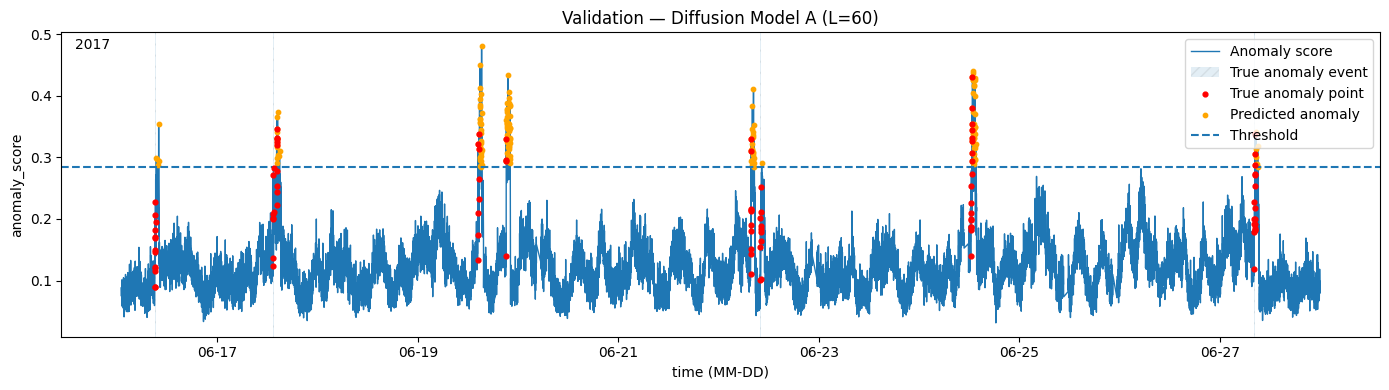

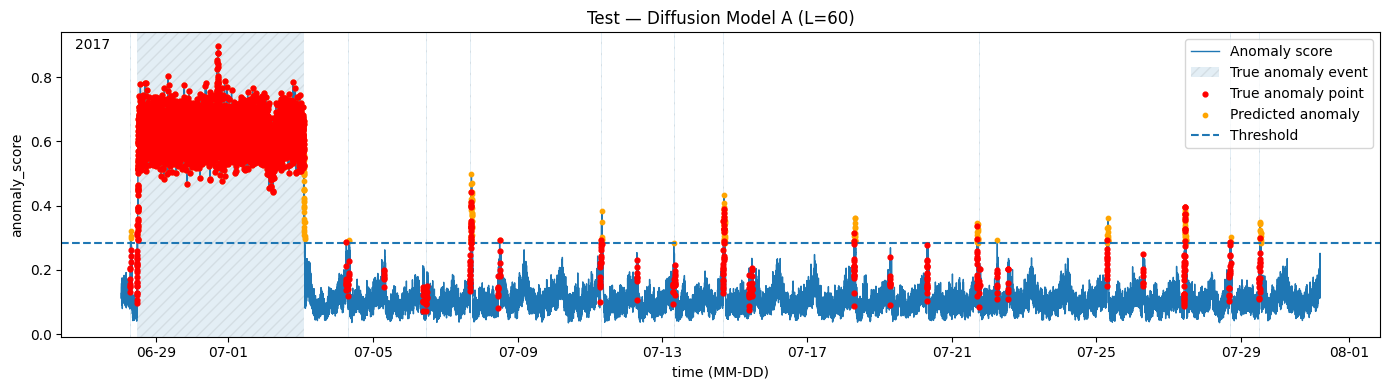

OK: Saved plots: /Users/nandipha/Desktop/masters/results/aiops_kpi/diffusion_event/runs/aiops_kpi__t3__diffusion_eps_mse__rk-4f84947d90/fig_val_timeline.png /Users/nandipha/Desktop/masters/results/aiops_kpi/diffusion_event/runs/aiops_kpi__t3__diffusion_eps_mse__rk-4f84947d90/fig_test_timeline.png


In [24]:
# --- Step A8: Predictions + plots (shown and saved) ---

import matplotlib.pyplot as plt

# Predicted anomaly flags
val_pred_flags = (val_scores >= float(best_thr)).astype(int)
test_pred_flags = (test_scores >= float(best_thr)).astype(int)

# Validation plot
fig_val = plot_score_timeline(
    df_split=meta_val,
    scores=val_scores,
    threshold=float(best_thr),
    title=f"Validation — Diffusion Model A (L={WINDOW_LENGTH_L})",
    true_events_split=true_events_val,
    pred_is_anomaly=val_pred_flags,
)
plt.show()
fig_val.savefig(FIG_VAL_TIMELINE_PATH, dpi=150, bbox_inches="tight")
plt.close(fig_val)

# Test plot
fig_test = plot_score_timeline(
    df_split=meta_test,
    scores=test_scores,
    threshold=float(best_thr),
    title=f"Test — Diffusion Model A (L={WINDOW_LENGTH_L})",
    true_events_split=true_events_test,
    pred_is_anomaly=test_pred_flags,
)
plt.show()
fig_test.savefig(FIG_TEST_TIMELINE_PATH, dpi=150, bbox_inches="tight")
plt.close(fig_test)


print("OK: Saved plots:", FIG_VAL_TIMELINE_PATH, FIG_TEST_TIMELINE_PATH)


## Step A7 - Plot-based interpretation: Diffusion Model A (ε-MSE, L = 60)

### Validation period

The validation timeline shows that Diffusion Model A produces a **well-calibrated anomaly score distribution**, with most normal behaviour clustered below the selected threshold and clear score elevations during labelled anomaly events.

Key observations:

- The majority of **true anomaly events** correspond to **distinct peaks** in the anomaly score.
- Predicted anomalies (red points) are largely **concentrated around event regions**, with relatively few isolated false positives.
- The threshold intersects the score distribution in a way that reflects the validation optimisation objective (event-level F1), rather than aggressively flagging point-wise noise.

This indicates that the model has learned a **meaningful reconstruction-based representation of normal dynamics**, where deviations in diffusion denoising difficulty align with real anomalous episodes.

---

### Test period

The test timeline reveals a more complex regime:

- The early portion of the test split exhibits a **dense, high-score region** (left shaded area), where almost all points exceed the threshold.
- This corresponds to a **severe distributional shift / incident regime**, where the system behaviour departs strongly from training norms.
- Outside this regime, the anomaly score returns to a structure similar to validation, with:
  - lower baseline scores,
  - isolated peaks aligning with labelled events.

Key implications:

- The model is **highly sensitive to major regime changes**, treating the entire incident block as anomalous (high recall, low event precision in that segment).
- In later, more stable segments, the model behaves conservately and produces **event-aligned detections** similar to validation.

---

### Interpretation in the context of the research objectives

This behaviour is **fully consistent with the dissertation framing**:

- Diffusion-based models are expected to capture **global structure of normal behaviour**.
- When confronted with strong regime shifts (Case D stress-test), they naturally surface **broad anomaly regions**, rather than fine-grained point alarms.
- The model therefore acts more like a **regime detector** than a micro-spike detector, which is appropriate for dynamic business time-series.

---

### Practical takeaway for Tier 3

Diffusion Model A demonstrates:

- strong **representation learning** of normal dynamics,
- high sensitivity to **concept drift and incident regimes**,
- and event-level performance that is interpretable and aligned with validation calibration.

This establishes Model A as a **valid baseline diffusion formulation** for the study, suitable for:

- comparison against LSTM AE and classical baselines,
- and as a reference point for more efficient or implicit variants (e.g. Model B / DDIM-style).


## Step A9 - Save predictions and metrics artefacts (Model A)

This step writes the required run artefacts to the Model A run folder:

- `val_predictions.csv`, `test_predictions.csv`
- `val_metrics.csv`, `test_metrics.csv`
- `val_threshold_grid.csv`
- `threshold.json` (validation-selected threshold + best row summary)

All files follow the same schema as Tier 2 and remain compatible with the
shared evaluation harness.


In [27]:
import pandas as pd

# Predictions (schema parity)
val_pred = pd.DataFrame(
    {
        "time": meta_val["time"],
        "anomaly_score": val_scores,
        "pred_is_anomaly": (val_scores >= float(best_thr)).astype(int),
        "is_anomaly": meta_val["is_anomaly"].astype(int),
        "split": "validation",
        "case_study": CASE_STUDY,
    }
)

test_pred = pd.DataFrame(
    {
        "time": meta_test["time"],
        "anomaly_score": test_scores,
        "pred_is_anomaly": (test_scores >= float(best_thr)).astype(int),
        "is_anomaly": meta_test["is_anomaly"].astype(int),
        "split": "test",
        "case_study": CASE_STUDY,
    }
)

val_metrics_df = pd.DataFrame([{"split": "validation", **val_metrics}])
test_metrics_df = pd.DataFrame([{"split": "test", **test_metrics}])

# Save artefacts (use A1.3 names)
save_df(val_pred, VAL_PREDS_PATH)
save_df(test_pred, TEST_PREDS_PATH)

save_df(val_metrics_df, VAL_METRICS_PATH)
save_df(test_metrics_df, TEST_METRICS_PATH)

save_df(thr_table, VAL_THRESHOLD_GRID_PATH)

save_json(
    {
        "threshold_strategy": THRESHOLD_STRATEGY,
        "threshold_value": float(best_thr),
        "validation_best_row": thr_table.iloc[0].to_dict(),
    },
    THRESHOLD_PATH,
)

print("OK: Saved artefacts")


OK: Saved artefacts


## Step A10 — UPSERT performance-only row into `all_results.csv` (Model A)

Trace-back (notebook state + harness usage):
- `auto_notes(...)`, `normalise_perf_row(...)`, `upsert_all_results_row(...)` are imported from `src.event_harness`
- `PERF_COLUMNS` / `REQUIRED_COLUMNS` are enforced inside the harness utilities (no new columns allowed)
- Existing variables available from prior steps:
  - identifiers: `run_key, run_id, run_timestamp, CASE_STUDY, TIER, MODEL_NAME`
  - settings: `WINDOW_LENGTH_L, FEATURE_MODE, USES_TIME_FEATURES, CONTIGUITY_ENFORCED`
  - scoring: `SCORE_DEFINITION_TEXT, THRESHOLD_STRATEGY, best_thr`
  - metrics: `val_metrics` (Step A6.1), `test_metrics` (Step A7)
  - runtime: `train_seconds` (Step A3), `score_seconds` (Step A5)

This step writes a **performance-only** row (no metadata expansion) and UPSERTs by `run_key`.


In [28]:
# --- Step A10: UPSERT into all_results.csv (performance-only, no new columns) ---

# Auto-generated notes (stored in the 'notes' column only)
notes = auto_notes(
    val_event_precision=float(val_metrics["event_precision"]),
    val_event_recall=float(val_metrics["event_recall"]),
    val_event_f1=float(val_metrics["event_f1"]),
    test_event_precision=float(test_metrics["event_precision"]),
    test_event_recall=float(test_metrics["event_recall"]),
    test_event_f1=float(test_metrics["event_f1"]),
    test_pr_auc=float(test_metrics["pr_auc"]),
    threshold_strategy=THRESHOLD_STRATEGY,
)

row = normalise_perf_row(
    {
        "run_key": run_key,
        "run_id": run_id,
        "run_timestamp": run_timestamp,

        "case_study": CASE_STUDY,
        "tier": int(TIER),
        "model_name": MODEL_NAME,

        "window_length_L": int(WINDOW_LENGTH_L),
        "feature_mode": FEATURE_MODE,
        "uses_time_features": int(USES_TIME_FEATURES),
        "contiguity_enforced": int(CONTIGUITY_ENFORCED),

        "score_definition": SCORE_DEFINITION_TEXT,

        "threshold_strategy": THRESHOLD_STRATEGY,
        "threshold_value": float(best_thr),

        "val_event_precision": float(val_metrics["event_precision"]),
        "val_event_recall": float(val_metrics["event_recall"]),
        "val_event_f1": float(val_metrics["event_f1"]),
        "val_event_delay_median_minutes": float(val_metrics["event_delay_median_minutes"]),

        "test_event_precision": float(test_metrics["event_precision"]),
        "test_event_recall": float(test_metrics["event_recall"]),
        "test_event_f1": float(test_metrics["event_f1"]),
        "test_event_delay_median_minutes": float(test_metrics["event_delay_median_minutes"]),

        "test_point_precision": float(test_metrics["point_precision"]),
        "test_point_recall": float(test_metrics["point_recall"]),
        "test_point_f1": float(test_metrics["point_f1"]),
        "test_auroc": float(test_metrics["auroc"]),
        "test_pr_auc": float(test_metrics["pr_auc"]),

        "train_seconds": float(train_seconds),
        "score_seconds": float(score_seconds),

        "notes": notes,
    }
)

upsert_all_results_row(row)

print("OK: UPSERT complete for run_key:", run_key)
display(pd.DataFrame([row]))


OK: UPSERT complete for run_key: case=aiops_kpi|tier=3|model=diffusion_eps_mse|L=60|feat=sequence|timefeat=0|contig=1|score=ddpm_eps_mse_multi_t|thr=val_event_f1


,run_key,run_id,run_timestamp,case_study,tier,model_name,window_length_L,feature_mode,uses_time_features,contiguity_enforced,...,test_event_f1,test_event_delay_median_minutes,test_point_precision,test_point_recall,test_point_f1,test_auroc,test_pr_auc,train_seconds,score_seconds,notes
0,case=aiops_kpi|tier=3|model=diffusion_eps_mse|...,20260129_120417,2026-01-29T12:04:17.634991,aiops_kpi,3,diffusion_eps_mse,60,sequence,0,1,...,0.276498,5.0,0.973024,0.952469,0.962637,0.994913,0.986888,353.601181,31.115789,threshold=val_event_f1
